# traQmania 06 — Scaling and features

[Notebook 04](04_training_the_quantum_driver.ipynb) ended with a first scaling
data point: on the oval, 6 qubits (5 lidar rays) learn exactly as fast as
4 qubits (3 rays) — and lap no faster. This notebook finishes that
investigation using the full training campaign shipped in
`data/histories/`, asking three questions:

1. **Do more qubits help?** The circuit encodes one observation scalar per
   qubit, so a wider circuit *is* a wider sensor array:
   4 → 6 → 8 → 10 qubits means 3 → 5 → 7 → 9 rays (plus speed).
2. **Are more rays the right way to spend those qubits?** Every extra ray
   costs a qubit, and every qubit doubles the simulated statevector.
3. **Or is a smarter observation the better trade?** Same qubit budget, with
   some rays swapped for engineered, track-aware features.

Nothing trains in this notebook — it re-plots pre-computed learning curves, so
it executes in seconds. Evaluation numbers are quoted from a greedy campaign
eval (deterministic policy, 6 standing-start episodes per trained snapshot,
exact `fastsim` statevector backend, one laptop) and are not recomputed here.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

hist_dir = next((b / "data" / "histories" for b in [Path.cwd(), *Path.cwd().parents]
                 if (b / "data" / "histories").is_dir()), None)
print("histories:", hist_dir)


def load_runs(pattern):
    '''History dicts matching data/histories/<pattern>, sorted by seed.'''
    if hist_dir is None:
        return []
    return sorted((json.loads(f.read_text()) for f in hist_dir.glob(pattern)),
                  key=lambda d: d["seed"])


def smooth(returns, window=25):
    '''(x, rolling mean) of per-episode returns.'''
    r = np.asarray(returns, dtype=float)
    if len(r) < window:
        return np.arange(len(r)), r
    return (np.arange(window - 1, len(r)),
            np.convolve(r, np.ones(window) / window, mode="valid"))

histories: /Users/majl/GitHub/traQmania/data/histories


## More qubits = more rays: the sensor-scaling campaign

The `q6`/`q8`/`q10` profiles widen the lidar fan — 5/7/9 rays plus speed, one
feature per qubit — and the circuit from
[notebook 03](03_quantum_circuits_as_q_functions.ipynb) grows as
$P = 3Ln + 8$ with $L = 4$ re-uploading layers: **56, 80, 104, 128
parameters** at 4, 6, 8, 10 qubits. The campaign trained every width on the
oval with the default schedule (double-DQN, $\varepsilon$ decayed over 250
episodes): `q6_oval_s*` (600 episodes, 3 seeds), `oval_q8_s*` (800 episodes,
5 seeds), `oval_q10_s*` (800 episodes, 4 seeds).

One caveat for the 4-qubit panel: the repo's original 4-qubit oval histories
(`hero_oval_s*`, 5 seeds) are 3000-episode runs with a slower exploration
schedule — first clean lap near episode 800 *by construction* — so their
take-off point is **not comparable** to the campaign runs. The like-for-like
4-qubit reference is notebook 04's live run: first lap after a few hundred
episodes, ~11 s of wall clock. The 4-qubit panel is therefore shown over its
full 3000 episodes: same return ceiling, stretched schedule. Compare lap
times and asymptotes across all four panels; compare take-off episodes only
across the last three.

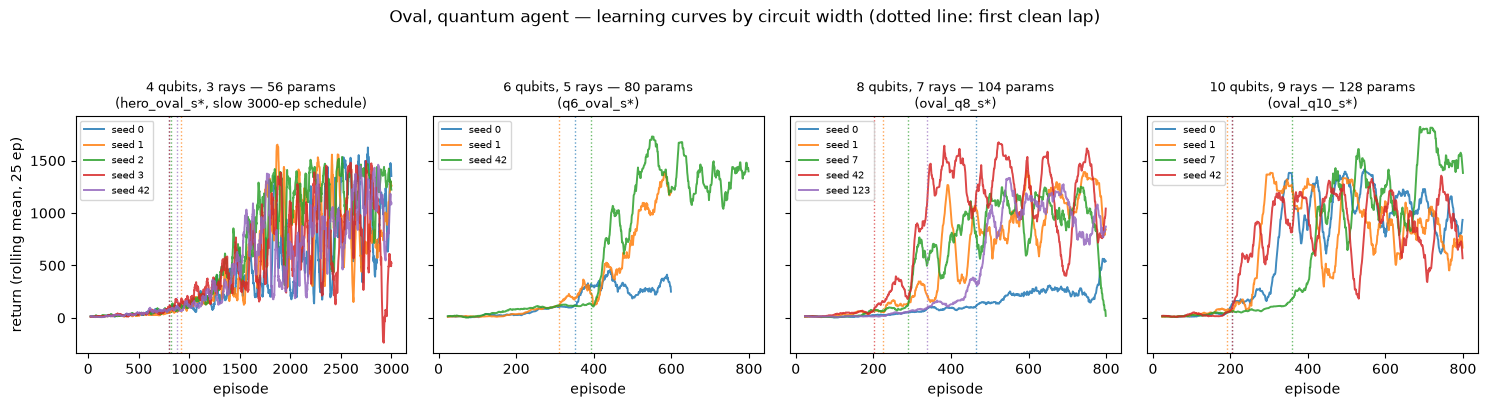

In [2]:
groups = [
    ("4 qubits, 3 rays — 56 params\n(hero_oval_s*, slow 3000-ep schedule)",
     "hero_oval_s*.history.json"),
    ("6 qubits, 5 rays — 80 params\n(q6_oval_s*)", "q6_oval_s*.history.json"),
    ("8 qubits, 7 rays — 104 params\n(oval_q8_s*)", "oval_q8_s*.history.json"),
    ("10 qubits, 9 rays — 128 params\n(oval_q10_s*)", "oval_q10_s*.history.json"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, (title, pattern) in zip(axes, groups, strict=True):
    for d in load_runs(pattern):
        x, y = smooth(d["episode_returns"])
        (line,) = ax.plot(x, y, lw=1.4, alpha=0.85, label=f"seed {d['seed']}")
        if d.get("first_clean_episode"):
            ax.axvline(d["first_clean_episode"], color=line.get_color(),
                       ls=":", lw=1, alpha=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("episode")
    ax.legend(fontsize=7)
axes[0].set_ylabel("return (rolling mean, 25 ep)")
fig.suptitle("Oval, quantum agent — learning curves by circuit width "
             "(dotted line: first clean lap)", y=1.06)
fig.tight_layout()
plt.show()

## The scaling table

First-clean-lap episodes below are read from the histories just plotted; the
greedy columns are quoted from the campaign eval (6 standing-start episodes
per snapshot, deterministic policy, `fastsim`). Decision latency is per greedy
action on one laptop whose load varied between campaign waves — read trends,
not digits. The trend has a simple cause: exact simulation tracks $2^n$
amplitudes, so 4 → 10 qubits is 16 → 1024 numbers per forward pass.

In [3]:
# Greedy-eval columns quoted from the campaign results (not recomputed here).
EVAL = {  # qubits: (observation, params, snapshots lapping greedily, best lap s, ms/decision)
    4:  ("3 rays + speed", 56, "bundled winner 6/6", 14.4, "~0.6"),
    6:  ("5 rays + speed", 80, "bundled winner 24 laps/8 eps", 14.7, "0.6-1.0"),
    8:  ("7 rays + speed", 104, "4/5 seeds 6/6 (seed 0: 0/6)", 14.0, "1.2-2.0"),
    10: ("9 rays + speed", 128, "3/4 seeds 6/6 (seed 42: 3/6)", 13.7, "4.6-8.7"),
}
CAMPAIGN = {6: "q6_oval_s*.history.json", 8: "oval_q8_s*.history.json",
            10: "oval_q10_s*.history.json"}

print(f"{'qubits':>6}{'params':>8}  {'observation':<17}{'first clean lap (episode)':<27}"
      f"{'greedy laps':<30}{'best lap':>9}{'ms/dec':>9}")
for n, (obs, p, robust, best, ms) in EVAL.items():
    if n in CAMPAIGN:
        first = ", ".join(str(d["first_clean_episode"]) for d in load_runs(CAMPAIGN[n]))
    else:
        first = "(slow schedule, see note)"
    print(f"{n:>6}{p:>8}  {obs:<17}{first:<27}{robust:<30}{best:>8.1f}s{ms:>9}")

qubits  params  observation      first clean lap (episode)  greedy laps                    best lap   ms/dec
     4      56  3 rays + speed   (slow schedule, see note)  bundled winner 6/6                14.4s     ~0.6
     6      80  5 rays + speed   352, 311, 392              bundled winner 24 laps/8 eps      14.7s  0.6-1.0
     8     104  7 rays + speed   465, 226, 290, 202, 339    4/5 seeds 6/6 (seed 0: 0/6)       14.0s  1.2-2.0
    10     128  9 rays + speed   203, 190, 358, 204         3/4 seeds 6/6 (seed 42: 3/6)      13.7s  4.6-8.7


What the campaign says:

- **Sample efficiency is flat.** Every width reaches its first clean lap in a
  few hundred episodes on the default schedule (q6 286–352, q8 226–465, q10
  190–259; notebook 04's live 4-qubit run sits in the same range). Extra rays
  neither accelerate nor slow learning on the oval.
- **Lap time barely moves — and robustness wobbles.** Best greedy laps of
  14.4 → 14.7 → 14.0 → 13.7 s across widths is a spread of a few percent,
  comparable to seed noise — and the wider circuits also produced their first
  outright greedy failures (q8 seed 0: 0/6; q10 seed 42: 3/6).
- **The cost grows anyway.** Greedy decision latency rises roughly an order of
  magnitude from 4 to 10 qubits. For a classical network an extra input scalar
  is nearly free; for a simulated quantum circuit each extra ray doubles the
  state.

So *more of the same input* scales the bill, not the driver. Which raises the
sharper question: can the same qubit budget buy a **better** input?

## Engineered features: spend qubits on smarter observations

Besides rays and speed, the env can emit track-aware scalars (all normalized
to $[0, 1]$ — see `RacingEnv._obs`):

- **`curvature_ahead`** — tightest centerline curvature within the next 15
  units, relative to the track's maximum: *how sharp is the next corner?*
- **`lateral_offset`** — signed centerline offset in half-widths: *where am I
  between the walls?*
- **`heading_error`** — wrapped angle to the track tangent (0.5 = aligned):
  *am I pointing the right way?*
- **`corner_speed_ratio`** — current speed over the fastest speed the car can
  hold through the corner ahead (0.5 = exactly at the limit): *will I make
  it?*

The campaign's feature profiles trade rays for features at a fixed qubit
count, so parameter counts match the plain profiles exactly:

| profile | qubits | observation | params |
|---|---|---|---|
| `q6feat` | 6 | 3 rays + speed + `curvature_ahead` + `corner_speed_ratio` | 80 |
| `q8feat` | 8 | 3 rays + speed + all four features | 104 |
| `q10feat` | 10 | 5 rays + speed + all four features | 128 |

(The packaged `q6`/`q8`/`q10` config files carry these observations as
commented-out alternatives you can enable.)

### Where `corner_speed_ratio` comes from

The car turns at $\dot\theta = \text{steer} \cdot k_\text{steer} \cdot f(v)$,
where the steering-authority falloff
$f(v) = 2\,v\,v_\text{turn} / (v_\text{turn}^2 + v^2)$ peaks at
$v = v_\text{turn}$ and fades at speed. Holding a circle of radius $R$
requires $\dot\theta = v / R$, so full lock ($\text{steer} = 1$) holds the
corner only while

$$\frac{v}{R} \;\le\; \frac{2\,k_\text{steer}\,v\,v_\text{turn}}{v_\text{turn}^2 + v^2}
\quad\Longleftrightarrow\quad
v \;\le\; v_\text{safe}(R) = \sqrt{2\,k_\text{steer}\,v_\text{turn}\,R - v_\text{turn}^2}.$$

`corner_speed_ratio` is $v / v_\text{safe}(R_\text{ahead})$ — the one number a
racing line cares about, handed to the circuit instead of hoping it
reconstructs the physics from raw rays.

In [4]:
from traqmania.config import load_config

phys = load_config()["physics"]
k_steer, v_turn = phys["k_steer"], phys["v_turn"]
print(f"k_steer={k_steer}, v_turn={v_turn}, v_max={phys['v_max']}")
print(f"tightest holdable corner: R = v_turn / (2 k_steer) = {v_turn / (2 * k_steer):.2f} units")
for radius in (2, 5, 10, 20, 40):
    v_safe = np.sqrt(max(0.0, 2 * k_steer * v_turn * radius - v_turn**2))
    print(f"  R = {radius:>2} units -> v_safe = {v_safe:5.1f}"
          + ("  (> v_max: flat out is fine)" if v_safe > phys["v_max"] else ""))

k_steer=2.6, v_turn=9.0, v_max=25.0
tightest holdable corner: R = v_turn / (2 k_steer) = 1.73 units
  R =  2 units -> v_safe =   3.5
  R =  5 units -> v_safe =  12.4
  R = 10 units -> v_safe =  19.7
  R = 20 units -> v_safe =  29.2  (> v_max: flat out is fine)
  R = 40 units -> v_safe =  42.3  (> v_max: flat out is fine)


### Oval: plain rays vs engineered features, same qubit budget

Same track, same schedule, same parameter count — only the observation
changes.

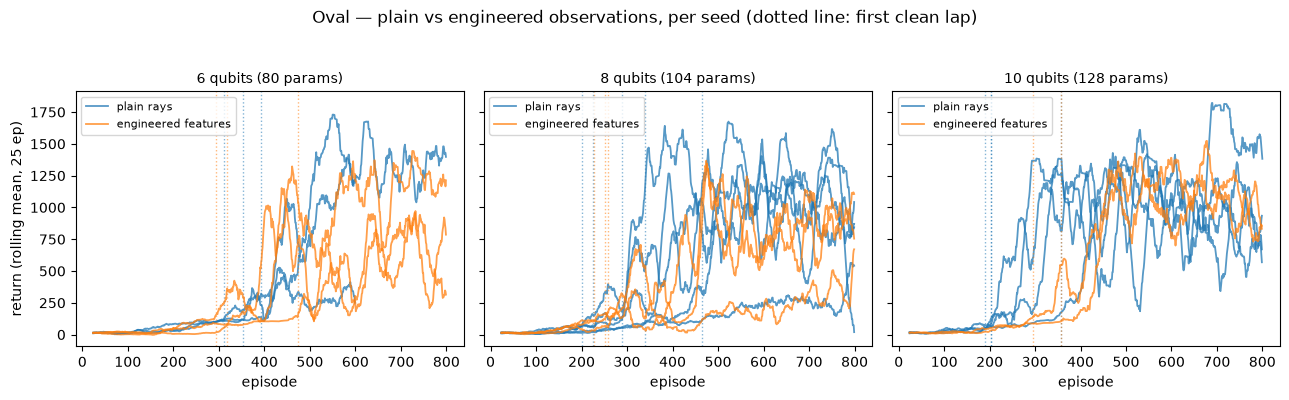

In [5]:
pairs = [
    ("6 qubits (80 params)", "q6_oval_s*.history.json", "featoval_q6_s*.history.json"),
    ("8 qubits (104 params)", "oval_q8_s*.history.json", "featoval_q8_s*.history.json"),
    ("10 qubits (128 params)", "oval_q10_s*.history.json", "featoval_q10_s*.history.json"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (title, plain_pat, feat_pat) in zip(axes, pairs, strict=True):
    for pat, color, label in ((plain_pat, "C0", "plain rays"),
                              (feat_pat, "C1", "engineered features")):
        for i, d in enumerate(load_runs(pat)):
            x, y = smooth(d["episode_returns"])
            ax.plot(x, y, color=color, lw=1.3, alpha=0.75,
                    label=label if i == 0 else None)
            if d.get("first_clean_episode"):
                ax.axvline(d["first_clean_episode"], color=color, ls=":", lw=1, alpha=0.55)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("episode")
    ax.legend(fontsize=8)
axes[0].set_ylabel("return (rolling mean, 25 ep)")
fig.suptitle("Oval — plain vs engineered observations, per seed "
             "(dotted line: first clean lap)", y=1.04)
fig.tight_layout()
plt.show()

In [6]:
# Greedy campaign eval, quantum agents: per-seed laps @ best lap (seed order 0/1/42
# unless noted). Quoted from the campaign results.
rows = [
    ("oval",    "q6  plain",  "bundled winner (seed 42): 24 laps over 8 eps @ 14.7s",       14.7),
    ("oval",    "q6  feat",   "6/6 @ 13.7s, 4/6 @ 13.8s, 6/6 @ 13.8s",                      13.7),
    ("oval",    "q8  plain",  "0/6, 6/6 @ 14.5s, 6/6 @ 16.3s, 6/6 @ 14.0s, 6/6 @ 16.2s"
                              " (seeds 0/1/7/42/123)",                                       14.0),
    ("oval",    "q8  feat",   "6/6 @ 13.9s, 6/6 @ 13.6s, 6/6 @ 13.8s",                      13.6),
    ("oval",    "q10 plain",  "6/6 @ 14.8s, 6/6 @ 16.2s, 6/6 @ 13.7s, 3/6 @ 16.1s"
                              " (seeds 0/1/7/42)",                                           13.7),
    ("oval",    "q10 feat",   "1/6 @ 14.2s, 6/6 @ 14.2s (seeds 0/42)",                      14.2),
    ("chicane", "q6  plain",  "5/6 @ 14.3s, 3/6 @ 14.7s, 6/6 @ 14.8s",                      14.3),
    ("chicane", "q6  feat",   "5/6 @ 15.8s, 6/6 @ 13.9s, 6/6 @ 15.7s",                      13.9),
]
print(f"{'track':<9}{'config':<11}{'greedy laps @ best lap, per seed':<66}{'best':>6}")
for track, cfg, per_seed, best in rows:
    print(f"{track:<9}{cfg:<11}{per_seed:<66}{best:>5.1f}s")

track    config     greedy laps @ best lap, per seed                                    best
oval     q6  plain  bundled winner (seed 42): 24 laps over 8 eps @ 14.7s               14.7s
oval     q6  feat   6/6 @ 13.7s, 4/6 @ 13.8s, 6/6 @ 13.8s                              13.7s
oval     q8  plain  0/6, 6/6 @ 14.5s, 6/6 @ 16.3s, 6/6 @ 14.0s, 6/6 @ 16.2s (seeds 0/1/7/42/123) 14.0s
oval     q8  feat   6/6 @ 13.9s, 6/6 @ 13.6s, 6/6 @ 13.8s                              13.6s
oval     q10 plain  6/6 @ 14.8s, 6/6 @ 16.2s, 6/6 @ 13.7s, 3/6 @ 16.1s (seeds 0/1/7/42) 13.7s
oval     q10 feat   1/6 @ 14.2s, 6/6 @ 14.2s (seeds 0/42)                              14.2s
chicane  q6  plain  5/6 @ 14.3s, 3/6 @ 14.7s, 6/6 @ 14.8s                              14.3s
chicane  q6  feat   5/6 @ 15.8s, 6/6 @ 13.9s, 6/6 @ 15.7s                              13.9s


At 6 and 8 qubits the engineered observation wins on both counts that matter:
best laps drop to **13.6–13.9 s** (vs 14.0–14.7 s plain — `featoval_q8`'s
13.6 s is the best quantum lap in the whole campaign) and robustness improves
(`featoval_q8`: every seed 6/6, where plain q8 had a 0/6 seed). Sample
efficiency is unchanged — first laps still arrive after a few hundred
episodes. At 10 qubits the picture muddies again: `featoval_q10` laps no
faster (14.2 s) and one of two seeds ends at 1/6. No free lunch — but on the
oval, two well-chosen scalars beat four extra rays.

### The honest failure — and the rescue: gp

This is the result that motivated the whole notebook. The **4-qubit** driver
(3 rays) handles gp, the hardest track: the bundled `quantum_gp` weights
greedy-lap it 6/6 at 20.4 s. Naively scaling up, **plain `q6` with 5 rays,
trained 3 seeds × 2000 episodes on gp, fails greedy evaluation almost
completely: 0/6, 0/6 and 1/6 episodes lapped.** The runs *do* lap during
$\varepsilon$-greedy training (curves below cross into lapping territory),
but the deterministic policies they converge to crash. More rays alone made
the hard track *worse* — which is why the repo deliberately bundles no
`quantum_gp_q6.npz` (the q6 server profile refuses gp modes instead of
shipping a broken driver).

Swap two rays for `curvature_ahead` + `corner_speed_ratio` — `q6feat`,
identical 80 parameters — and gp comes back: greedy **5/6 at 23.3 s** and
**4/6 at 23.1 s** on two of three seeds (the third still fails, 0/6). A
rescue, not a triumph: the feature variant laps gp but slower than the
4-qubit specialist (20.4 s), and one seed in three still doesn't transfer
from training to greedy driving.

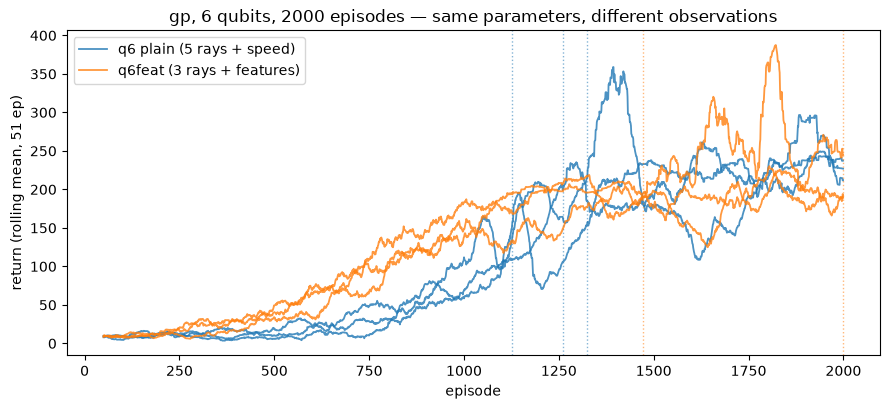

greedy eval on gp (6 standing-start episodes, per seed 0/1/42):
  q6 plain :  0/6,          0/6,  1/6 @ 21.0s   <- not bundled, on purpose
  q6feat   :  5/6 @ 23.3s,  0/6,  4/6 @ 23.1s
  4q ref   :  6/6 @ 20.4s   (bundled quantum_gp)


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for pat, color, label in (("gp_q6_s*.history.json", "C0", "q6 plain (5 rays + speed)"),
                          ("featgp_q6_s*.history.json", "C1", "q6feat (3 rays + features)")):
    for i, d in enumerate(load_runs(pat)):
        x, y = smooth(d["episode_returns"], window=51)
        ax.plot(x, y, color=color, lw=1.3, alpha=0.8, label=label if i == 0 else None)
        if d.get("first_clean_episode"):
            ax.axvline(d["first_clean_episode"], color=color, ls=":", lw=1, alpha=0.55)
ax.set_xlabel("episode")
ax.set_ylabel("return (rolling mean, 51 ep)")
ax.set_title("gp, 6 qubits, 2000 episodes — same parameters, different observations")
ax.legend()
fig.tight_layout()
plt.show()

print("greedy eval on gp (6 standing-start episodes, per seed 0/1/42):")
print("  q6 plain :  0/6,          0/6,  1/6 @ 21.0s   <- not bundled, on purpose")
print("  q6feat   :  5/6 @ 23.3s,  0/6,  4/6 @ 23.1s")
print("  4q ref   :  6/6 @ 20.4s   (bundled quantum_gp)")

### Do features help everyone? The MLP control

If the engineered observation simply made the task easier, the matched MLP
baseline (same observations, 92 parameters, ~0.01 ms/decision) should improve
too. It doesn't:

In [8]:
# Greedy-eval columns quoted from the campaign; first-clean episodes computed
# from the shipped histories (seed order 0/1/42).
mlp_rows = (
    ("rays (5 + speed)", "mlp_oval_q6_s*.history.json",
     "6/6 @ 14.1s, 6/6 @ 14.1s, 6/6 @ 13.7s"),
    ("engineered (q6feat)", "mlp_featoval_q6_s*.history.json",
     "6/6 @ 14.5s, 6/6 @ 14.1s, 6/6 @ 14.6s"),
)
print(f"{'MLP observation':<22}{'first clean lap (episode)':<28}{'greedy laps @ best lap':<42}")
for label, pattern, evals in mlp_rows:
    firsts = ", ".join(str(d["first_clean_episode"]) for d in load_runs(pattern))
    print(f"{label:<22}{firsts:<28}{evals:<42}")

MLP observation       first clean lap (episode)   greedy laps @ best lap                    
rays (5 + speed)      123, 130, 150               6/6 @ 14.1s, 6/6 @ 14.1s, 6/6 @ 13.7s     
engineered (q6feat)   208, 152, 151               6/6 @ 14.5s, 6/6 @ 14.1s, 6/6 @ 14.6s     


The MLP was already at 13.7–14.1 s from raw rays and got slightly *slower*
with features (14.1–14.6 s), while learning no faster. So the engineered
observation helped the quantum circuit specifically — consistent with the
intuition that an 80-parameter, 4-layer circuit has less spare capacity to
synthesize $v / v_\text{safe}$ from raw rays than even a tiny MLP. But keep
the epistemics straight: **one environment, three seeds, features hand-built
for this exact car model. This is an observation worth probing, not a
claim.**

## Does any of this survive shots?

Everything above used the exact statevector.
[Notebook 05](05_real_quantum_hardware.ipynb) covers real hardware; here is
the campaign's 1024-shot Aer sanity check of two sensor-scaling snapshots
(same greedy protocol, numbers quoted — nothing executes on hardware in this
notebook):

In [9]:
print(f"{'snapshot':<16}{'exact fastsim':<30}{'Aer, 1024 shots':<30}")
print(f"{'oval q8, s1':<16}{'6/6 laps, 14.5s, ~1.7 ms/dec':<30}{'6/6 laps, 14.5s, ~18 ms/dec':<30}")
print(f"{'oval q10, s42':<16}{'3/6 laps, 16.1s, ~8.7 ms/dec':<30}"
      f"{'3/6 laps, 16.1s, ~24 ms/dec':<30}")

snapshot        exact fastsim                 Aer, 1024 shots               
oval q8, s1     6/6 laps, 14.5s, ~1.7 ms/dec  6/6 laps, 14.5s, ~18 ms/dec   
oval q10, s42   3/6 laps, 16.1s, ~8.7 ms/dec  3/6 laps, 16.1s, ~24 ms/dec   


The robust 8-qubit policy is unchanged by 1024-shot sampling — its Q-value
gaps are wide enough that sampling noise doesn't flip action choices. The
10-qubit snapshot tested was already marginal under exact simulation (3/6)
and stays exactly as marginal under shots. The real casualty is latency:
18–24 ms per decision starts to eat into a 10 Hz control budget before any
real-device queue or noise enters the picture.

## What this shows — and what it doesn't

Same rules as [notebook 04](04_training_the_quantum_driver.ipynb): honesty
over excitement.

- **Parity, still not advantage.** Every quantum result here is matched or
  beaten by a tiny MLP at roughly 1/100th the decision latency (best oval
  laps: quantum 13.6 s vs MLP 13.5 s at q10-matched size; gp: quantum-feat
  23.1 s vs MLP 19.2 s). This campaign characterizes *how a small VQC
  scales*; it demonstrates no quantum usefulness, and none should be
  inferred.
- **More qubits bought nothing on their own.** Flat sample efficiency, lap
  times within seed noise, new robustness failures (q8 seed 0, q10 seed 42),
  and exponentially growing simulation cost.
- **More rays actively regressed the hard track**, and the repo owns that:
  plain q6 fails greedy gp on all three seeds, so `quantum_gp_q6.npz` is
  deliberately not bundled. An honest scaling limitation beats a quietly
  broken weight file.
- **Engineered features helped the VQC and not the MLP** — the most
  interesting single observation in the campaign, and the least established:
  one environment, three seeds, features derived from the simulator's own
  physics. Treat it as a hypothesis about small-circuit capacity, not a
  finding about quantum models.
- **Watch the selection effects.** "Best greedy lap" columns favor whichever
  variant had more evaluated snapshots; the per-seed robustness columns are
  the ones that carry information.

## Outlook: one driver, any track — measured

The bundled 4-qubit weights already hinted at transfer: the gp-trained
specialist zero-shot laps *all three* tracks greedily (20.4 s gp / 15.8 s
oval / 16.1 s chicane) and 10/10 unseen procedurally generated tracks at
medium difficulty, while the oval and chicane specialists lap each other's
tracks but fail 0/6 on gp — the hard track teaches transferable driving; the
easy ones don't.

The follow-up campaign (histories `multi_*` / `random_*` in
`data/histories/`) trained single drivers across tracks, 2500 episodes each:

- **`--track multi`** (oval+chicane+gp round-robin, 4 qubits): seed 42
  produced the bundled **`quantum_universal.npz`** — oval 14.3 s, chicane
  14.8 s, gp 25.7 s, 10/10 generated tracks at difficulty 0.5 (7/10 at 0.8).
  It beats the gp specialist's zero-shot laps on oval/chicane but stays
  slower than specialists at home. Seed-honesty: seeds 0 and 1 lapped
  oval+chicane fast (13.7–14.2 s) yet failed gp 0/6 — one seed in three
  generalized.
- **`--track multi` with the q6 feature observation**: fastest oval/chicane
  laps of the wave (13.7–13.9 s) but 0/6 on gp for all three seeds — the
  engineered features did not rescue multi-track gp the way they rescued
  single-track gp training.
- **`--track random`** (pools of generated tracks only): laps generated
  tracks (4–9/10) but mostly fails the bundled circuits — domain
  randomization alone didn't cover gp-style geometry.

So a 4-qubit circuit *can* be a universal driver — when the hard track is in
the training mix and the seed cooperates. In the demo, the universal weights
drive every 🎲 surprise track, and the Watch-mode driver picker lets you race
any specialist on any track to see the transfer (and its limits) live.